# Hyper Parameter Tuning and cross validatioon

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate synthetic data
X, y = make_classification(
    n_samples=1000,
    n_features=2,           # Use 2 for easy plotting
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    random_state=42
)

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [59]:
from sklearn.linear_model import LogisticRegression

penalty = ['l1', 'l2', 'elasticnet']
c_values = [0.01, 0.1, 1, 10, 100]
solver = ['liblinear', 'saga', 'lbfgs', 'newton-cg', 'sag']


In [60]:
# params = dict(penalty=penalty, C=c_values, solver=solver)

param_grid = [
    {'penalty': ['l1'], 'C': c_values, 'solver': ['liblinear', 'saga']},
    {'penalty': ['l2'], 'C': c_values, 'solver': ['liblinear', 'saga', 'lbfgs', 'newton-cg', 'sag']},
    {'penalty': ['elasticnet'], 'C': c_values, 'solver': ['saga'], 'l1_ratio': [0.5]}
]

In [61]:
from sklearn.model_selection import GridSearchCV

model = LogisticRegression(max_iter=1000)
grid = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)


{'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}
0.8699999999999999


# Randomized Searchg cv

In [63]:
from sklearn.model_selection import RandomizedSearchCV

rndomxv = RandomizedSearchCV(model, param_distributions=param_grid, cv=5, scoring="accuracy")
rndomxv.fit(X_train, y_train)
print(rndomxv.best_params_)
print(rndomxv.best_score_)

{'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': 0.5, 'C': 0.01}
0.8699999999999999


# Multiclass Classifctiaon

Classification Report:

              precision    recall  f1-score   support

     Class 0       0.66      0.75      0.70        67
     Class 1       0.58      0.39      0.46        67
     Class 2       0.67      0.80      0.73        66

    accuracy                           0.65       200
   macro avg       0.64      0.65      0.63       200
weighted avg       0.64      0.65      0.63       200



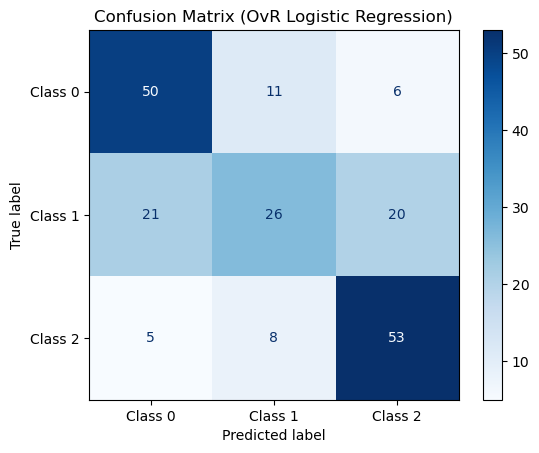

In [3]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate synthetic data
X, y = make_classification(
    n_samples=1000,
    n_features=3,
    n_informative=3,
    n_redundant=0,
    n_classes=3,
    random_state=42
)

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Logistic Regression (One-vs-Rest)
model = LogisticRegression(multi_class='ovr', solver='liblinear', max_iter=200)
model.fit(X_train, y_train)

# 4. Predict
y_pred = model.predict(X_test)

# 5. Labels (since we used synthetic data)
target_names = [f"Class {i}" for i in np.unique(y)]

# 6. Evaluation
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (OvR Logistic Regression)")
plt.show()
